
Identifying top variables associated with assignment completion using correlation heatmap:

Correlation with Assignment Completion Rate:


,assignment_completion_rate_original
assignment_completion_rate_original,1.000000
discussion_participation_count,0.051674
quiz_avg_score,0.046599
sessions_per_week,0.007232
videos_watched_percent,-0.035508
avg_session_minutes,-0.060133
inactive_streak_days,-0.081600
days_since_last_activity,-0.081600


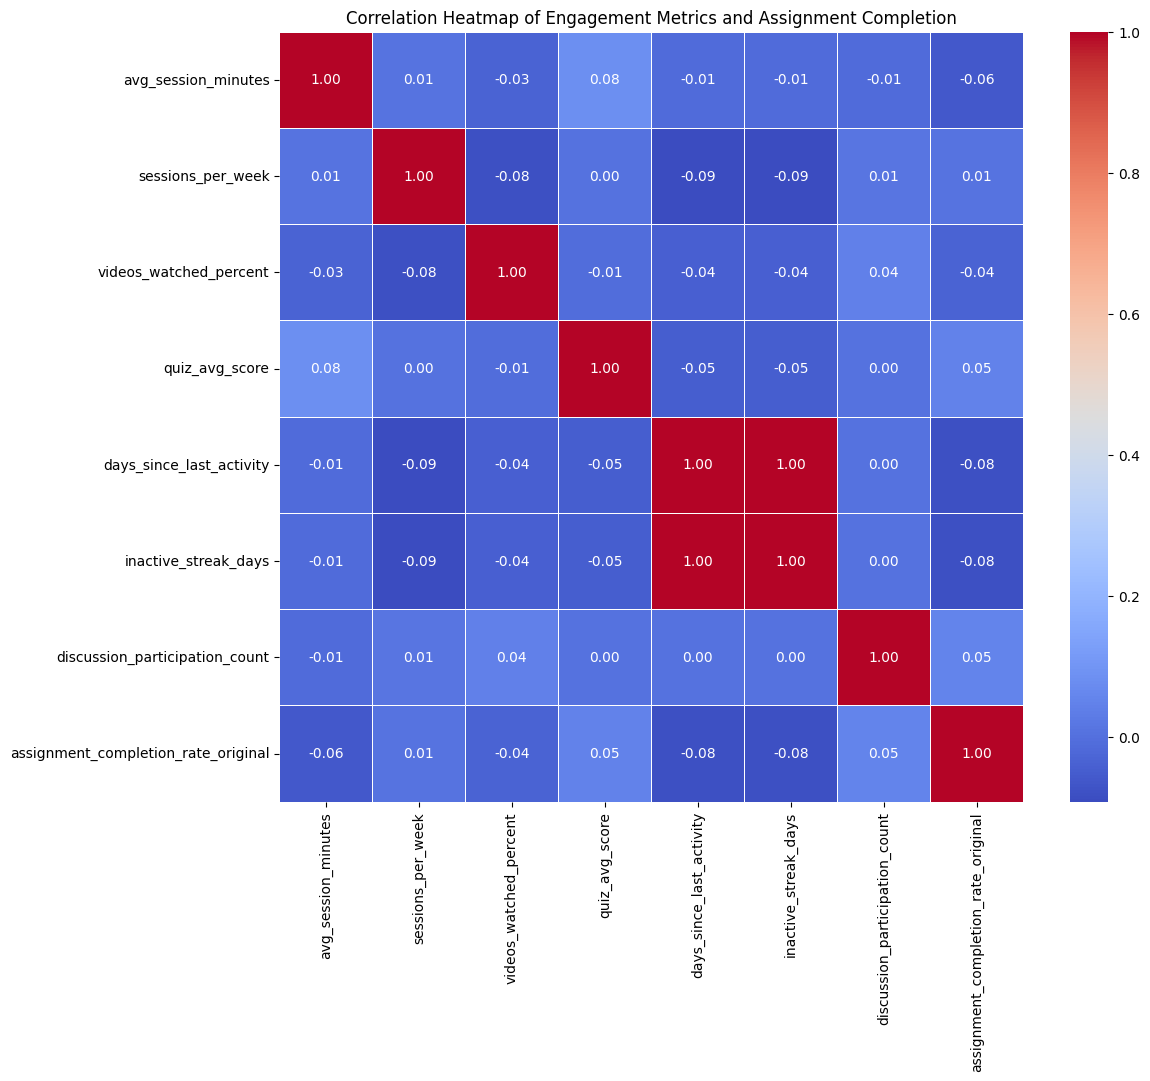

In [17]:
print("\nIdentifying top variables associated with assignment completion using correlation heatmap:")

# Select relevant numerical columns for correlation analysis, including the original assignment_completion_rate
# Re-calculate assignment_completion_rate using original columns as the df['assignment_completion_rate'] was standardized
correlation_df = df[['avg_session_minutes', 'sessions_per_week', 'videos_watched_percent',
                     'quiz_avg_score', 'days_since_last_activity', 'inactive_streak_days',
                     'discussion_participation_count']].copy()

correlation_df['assignment_completion_rate_original'] = df['assignments_completed'] / df['assignments_total']
correlation_df['assignment_completion_rate_original'] = correlation_df['assignment_completion_rate_original'].fillna(0)

# Calculate the correlation matrix
correlation_matrix = correlation_df.corr()

# Filter for correlations with 'assignment_completion_rate_original'
assignment_completion_corr = correlation_matrix['assignment_completion_rate_original'].sort_values(ascending=False)
print("\nCorrelation with Assignment Completion Rate:")
display(assignment_completion_corr)

# Plot the heatmap for all selected variables
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Heatmap of Engagement Metrics and Assignment Completion')
plt.show()

In [1]:
import pandas as pd

# Load the dataset
df = pd.read_csv('/content/student_dropout_risk_dataset.csv')

# Display the first 5 rows of the DataFrame
print('First 5 rows of the dataset:')
display(df.head())

First 5 rows of the dataset:


,student_id,course_id,country,age_group,enrollment_date,last_login_date,avg_session_minutes,sessions_per_week,videos_watched_percent,assignments_completed,assignments_total,quiz_avg_score,days_since_last_activity,inactive_streak_days,discussion_participation_count,certificate_earned
0,S1,C4,India,28-35,2024-06-18,2024-07-02,68.6,2.9,95.6,2,7,64.9,4,4,11,No
1,S2,C8,Canada,28-35,2024-09-06,2024-10-28,14.6,1.5,24.0,2,5,85.0,18,18,6,No
2,S3,C4,USA,28-35,2024-12-09,2025-03-17,11.6,4.4,73.7,1,8,92.7,5,5,4,No
3,S4,C7,UAE,23-27,2024-05-12,2024-05-25,24.5,5.9,29.1,6,7,33.8,15,15,12,Yes
4,S5,C2,UK,23-27,2024-09-17,2024-12-02,44.6,2.5,57.2,2,6,41.8,5,5,9,No


In [2]:
# Inspect the shape of the DataFrame
print('\nShape of the dataset (rows, columns):', df.shape)

# Inspect the columns and their data types
print('\nColumn information and data types:')
display(df.info())


Shape of the dataset (rows, columns): (400, 16)

Column information and data types:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   student_id                      400 non-null    object 
 1   course_id                       400 non-null    object 
 2   country                         400 non-null    object 
 3   age_group                       400 non-null    object 
 4   enrollment_date                 400 non-null    object 
 5   last_login_date                 400 non-null    object 
 6   avg_session_minutes             400 non-null    float64
 7   sessions_per_week               400 non-null    float64
 8   videos_watched_percent          400 non-null    float64
 9   assignments_completed           400 non-null    int64  
 10  assignments_total               400 non-null    int64  
 11  quiz_avg_sco

None

In [3]:
# Check for missing values
print('\nMissing values in each column:')
display(df.isnull().sum())


Missing values in each column:


,0
student_id,0
course_id,0
country,0
age_group,0
enrollment_date,0
last_login_date,0
avg_session_minutes,0
sessions_per_week,0
videos_watched_percent,0
assignments_completed,0


In [4]:
# Calculate average engagement metrics
avg_session_minutes = df['avg_session_minutes'].mean()
avg_quiz_score = df['quiz_avg_score'].mean()
avg_assignments_completed = df['assignments_completed'].mean()

print(f"Average Session Minutes: {avg_session_minutes:.2f}")
print(f"Average Quiz Score: {avg_quiz_score:.2f}")
print(f"Average Assignments Completed: {avg_assignments_completed:.2f}")

Average Session Minutes: 48.24
Average Quiz Score: 58.92
Average Assignments Completed: 3.62



Analyzing relationship between sessions_per_week and assignments_completed:


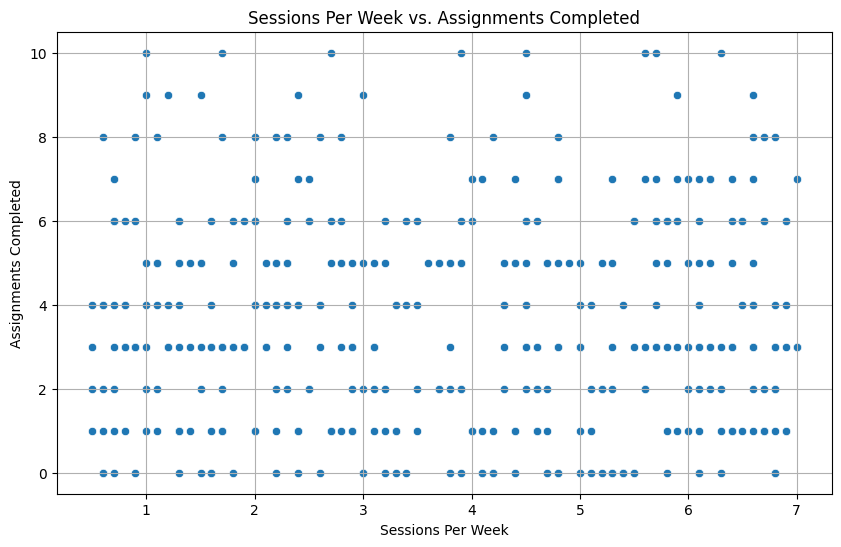

Correlation between Sessions Per Week and Assignments Completed: -0.00


In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

# Analyze relationship between sessions_per_week and assignments_completed
print("\nAnalyzing relationship between sessions_per_week and assignments_completed:")

# Create a scatter plot
plt.figure(figsize=(10, 6))
sns.scatterplot(x='sessions_per_week', y='assignments_completed', data=df)
plt.title('Sessions Per Week vs. Assignments Completed')
plt.xlabel('Sessions Per Week')
plt.ylabel('Assignments Completed')
plt.grid(True)
plt.show()

# Calculate the correlation coefficient
correlation = df['sessions_per_week'].corr(df['assignments_completed'])
print(f"Correlation between Sessions Per Week and Assignments Completed: {correlation:.2f}")


Analyzing impact of videos_watched_percent on certificate completion:

Descriptive statistics of videos_watched_percent by certificate_earned:


,count,mean,std,min,25%,50%,75%,max
certificate_earned,,,,,,,,
No,318.0,55.402201,25.678294,11.0,32.475,56.05,76.375,99.7
Yes,82.0,52.653659,26.687923,10.4,29.275,47.45,74.075,99.1


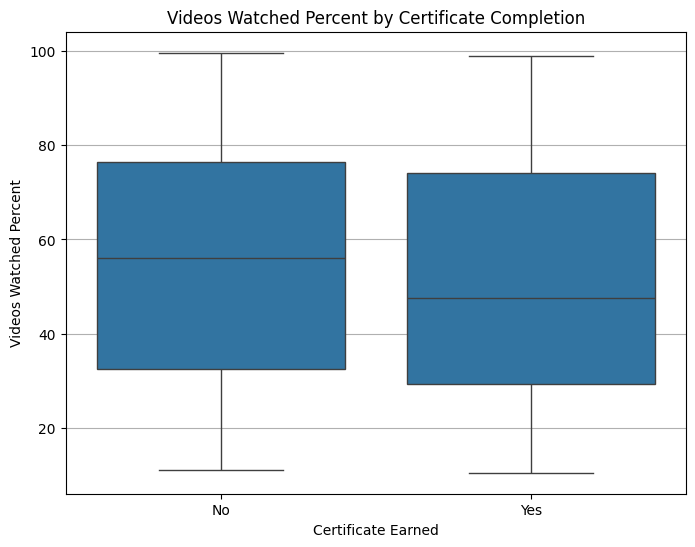

In [6]:
print("\nAnalyzing impact of videos_watched_percent on certificate completion:")

# Convert 'certificate_earned' to a more suitable format (e.g., boolean or 0/1)
df['certificate_earned_binary'] = df['certificate_earned'].apply(lambda x: 1 if x == 'Yes' else 0)

# Group by certificate_earned and describe videos_watched_percent
print("\nDescriptive statistics of videos_watched_percent by certificate_earned:")
display(df.groupby('certificate_earned')['videos_watched_percent'].describe())

# Visualize the relationship with a box plot
plt.figure(figsize=(8, 6))
sns.boxplot(x='certificate_earned', y='videos_watched_percent', data=df)
plt.title('Videos Watched Percent by Certificate Completion')
plt.xlabel('Certificate Earned')
plt.ylabel('Videos Watched Percent')
plt.grid(axis='y')
plt.show()


Analyzing inactivity patterns using days_since_last_activity:

Descriptive statistics for days_since_last_activity:


,days_since_last_activity
count,400.000000
mean,9.972500
std,6.059583
min,0.000000
25%,5.000000
50%,10.000000
75%,15.000000
max,20.000000


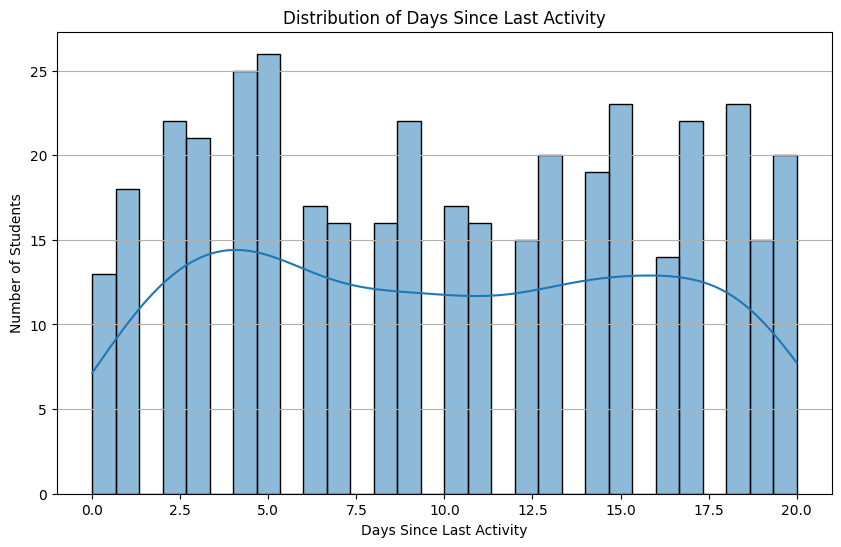

In [7]:
print("\nAnalyzing inactivity patterns using days_since_last_activity:")

# Display descriptive statistics for days_since_last_activity
print("\nDescriptive statistics for days_since_last_activity:")
display(df['days_since_last_activity'].describe())

# Visualize the distribution of days_since_last_activity
plt.figure(figsize=(10, 6))
sns.histplot(df['days_since_last_activity'], bins=30, kde=True)
plt.title('Distribution of Days Since Last Activity')
plt.xlabel('Days Since Last Activity')
plt.ylabel('Number of Students')
plt.grid(axis='y')
plt.show()


Visualizing inactive_streak_days distribution:

Descriptive statistics for inactive_streak_days:


,inactive_streak_days
count,400.000000
mean,9.972500
std,6.059583
min,0.000000
25%,5.000000
50%,10.000000
75%,15.000000
max,20.000000


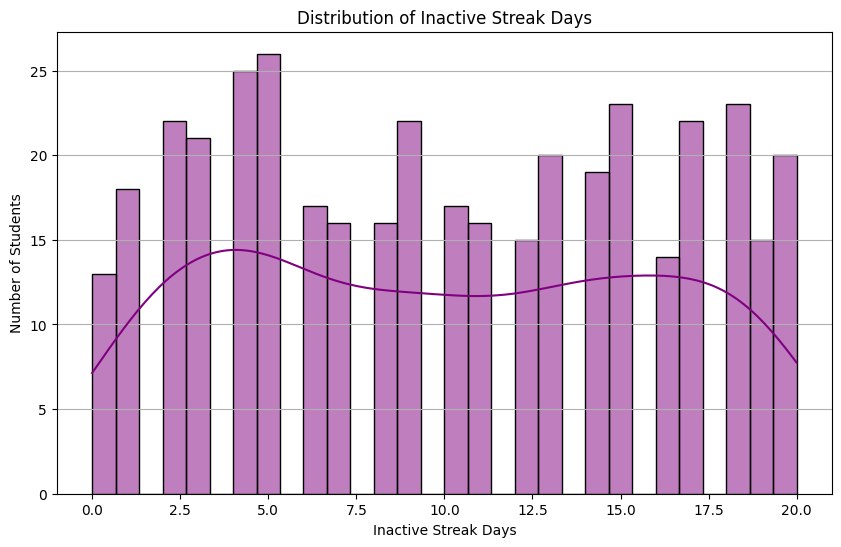

In [8]:
print("\nVisualizing inactive_streak_days distribution:")

# Display descriptive statistics for inactive_streak_days
print("\nDescriptive statistics for inactive_streak_days:")
display(df['inactive_streak_days'].describe())

# Visualize the distribution of inactive_streak_days
plt.figure(figsize=(10, 6))
sns.histplot(df['inactive_streak_days'], bins=30, kde=True, color='purple')
plt.title('Distribution of Inactive Streak Days')
plt.xlabel('Inactive Streak Days')
plt.ylabel('Number of Students')
plt.grid(axis='y')
plt.show()

In [9]:
print("\nCreating assignment_completion_rate feature:")

# Create assignment_completion_rate feature
df['assignment_completion_rate'] = df['assignments_completed'] / df['assignments_total']

# Handle potential division by zero if assignments_total can be 0 (though unlikely here)
df['assignment_completion_rate'] = df['assignment_completion_rate'].fillna(0)

print("Added 'assignment_completion_rate' column. Displaying first 5 rows with the new column:")
display(df[['student_id', 'assignments_completed', 'assignments_total', 'assignment_completion_rate']].head())


Creating assignment_completion_rate feature:
Added 'assignment_completion_rate' column. Displaying first 5 rows with the new column:


,student_id,assignments_completed,assignments_total,assignment_completion_rate
0,S1,2,7,0.285714
1,S2,2,5,0.400000
2,S3,1,8,0.125000
3,S4,6,7,0.857143
4,S5,2,6,0.333333


In [10]:
from sklearn.preprocessing import StandardScaler

print("\nBuilding engagement category column (High / Medium / Low):")

# Define engagement metrics for scoring
engagement_metrics = [
    'avg_session_minutes',
    'sessions_per_week',
    'videos_watched_percent',
    'assignment_completion_rate'
]

# Standardize the engagement metrics
scaler = StandardScaler()
df[engagement_metrics] = scaler.fit_transform(df[engagement_metrics])

# Create a composite engagement score by summing the standardized metrics
df['engagement_score'] = df[engagement_metrics].sum(axis=1)

# Define engagement categories based on quantiles of the engagement score
# For example, bottom 33% as 'Low', middle 34% as 'Medium', top 33% as 'High'
low_quantile = df['engagement_score'].quantile(0.33)
high_quantile = df['engagement_score'].quantile(0.67)

def categorize_engagement(score):
    if score <= low_quantile:
        return 'Low'
    elif score <= high_quantile:
        return 'Medium'
    else:
        return 'High'

df['engagement_category'] = df['engagement_score'].apply(categorize_engagement)

print("Added 'engagement_score' and 'engagement_category' columns. Displaying value counts:")
display(df['engagement_category'].value_counts())
display(df[['student_id', 'engagement_score', 'engagement_category']].head())


Building engagement category column (High / Medium / Low):
Added 'engagement_score' and 'engagement_category' columns. Displaying value counts:


,count
engagement_category,
Medium,136
High,132
Low,132


,student_id,engagement_score,engagement_category
0,S1,1.348873,High
1,S2,-4.077908,Low
2,S3,-1.682401,Low
3,S4,0.205515,Medium
4,S5,-1.215171,Low


In [11]:
print("\nCreating dropout risk classification column:")

# Define metrics for risk assessment
risk_metrics_positive = ['inactive_streak_days', 'days_since_last_activity'] # Higher value = higher risk
risk_metrics_negative = ['assignment_completion_rate', 'quiz_avg_score', 'videos_watched_percent'] # Lower value = higher risk

# Standardize the risk metrics
scaler_risk = StandardScaler()
# For positively correlated risk metrics, use directly
df[risk_metrics_positive] = scaler_risk.fit_transform(df[risk_metrics_positive])

# For negatively correlated risk metrics, standardize and then negate
df[risk_metrics_negative] = scaler_risk.fit_transform(df[risk_metrics_negative])
df[[f'{col}_inverted' for col in risk_metrics_negative]] = -df[risk_metrics_negative]

# Create a composite risk score
risk_score_cols = risk_metrics_positive + [f'{col}_inverted' for col in risk_metrics_negative]
df['dropout_risk_score'] = df[risk_score_cols].sum(axis=1)

# Define risk categories based on quantiles of the dropout_risk_score
low_risk_quantile = df['dropout_risk_score'].quantile(0.33)
high_risk_quantile = df['dropout_risk_score'].quantile(0.67)

def categorize_risk(score):
    if score <= low_risk_quantile:
        return 'Low Risk'
    elif score <= high_risk_quantile:
        return 'Medium Risk'
    else:
        return 'High Risk'

df['dropout_risk_classification'] = df['dropout_risk_score'].apply(categorize_risk)

print("Added 'dropout_risk_score' and 'dropout_risk_classification' columns. Displaying value counts:")
display(df['dropout_risk_classification'].value_counts())
display(df[['student_id', 'dropout_risk_score', 'dropout_risk_classification']].head())


Creating dropout risk classification column:
Added 'dropout_risk_score' and 'dropout_risk_classification' columns. Displaying value counts:


,count
dropout_risk_classification,
Medium Risk,136
Low Risk,132
High Risk,132


,student_id,dropout_risk_score,dropout_risk_classification
0,S1,-3.158253,Low Risk
1,S2,2.943462,High Risk
2,S3,-2.768631,Low Risk
3,S4,2.699259,High Risk
4,S5,-0.416773,Medium Risk



Comparing completion rate across risk categories:
Average actual assignment completion rate by risk category:


,actual_assignment_completion_rate
dropout_risk_classification,
Low Risk,0.630934
Medium Risk,0.511450
High Risk,0.353905


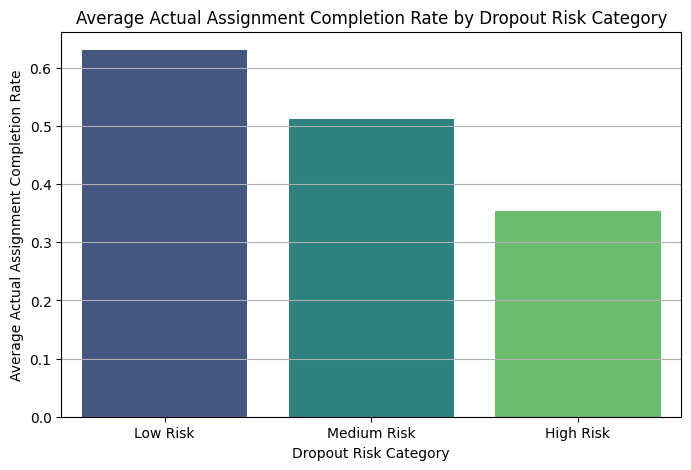

In [13]:
print("\nComparing completion rate across risk categories:")

# Temporarily recalculate the actual assignment completion rate for comparison
# Note: The 'assignment_completion_rate' column in df was modified for risk scoring.
# We need the original completion rate for this comparison.
actual_assignment_completion_rate = df['assignments_completed'] / df['assignments_total']
actual_assignment_completion_rate = actual_assignment_completion_rate.fillna(0)

# Create a temporary DataFrame for grouping with the correct completion rate
temp_df = pd.DataFrame({
    'dropout_risk_classification': df['dropout_risk_classification'],
    'actual_assignment_completion_rate': actual_assignment_completion_rate
})

# Group by dropout_risk_classification and calculate the mean actual_assignment_completion_rate
completion_rate_by_risk = temp_df.groupby('dropout_risk_classification')['actual_assignment_completion_rate'].mean().sort_values(ascending=False)

print("Average actual assignment completion rate by risk category:")
display(completion_rate_by_risk)

# Visualize the comparison using a bar plot
plt.figure(figsize=(8, 5))
sns.barplot(x=completion_rate_by_risk.index, y=completion_rate_by_risk.values, palette='viridis', hue=completion_rate_by_risk.index, legend=False)
plt.title('Average Actual Assignment Completion Rate by Dropout Risk Category')
plt.xlabel('Dropout Risk Category')
plt.ylabel('Average Actual Assignment Completion Rate')
plt.grid(axis='y')
plt.show()


Comparing quiz scores across risk categories:
Average original quiz score by risk category:


,original_quiz_avg_score
dropout_risk_classification,
Low Risk,66.700000
Medium Risk,61.763971
High Risk,48.216667


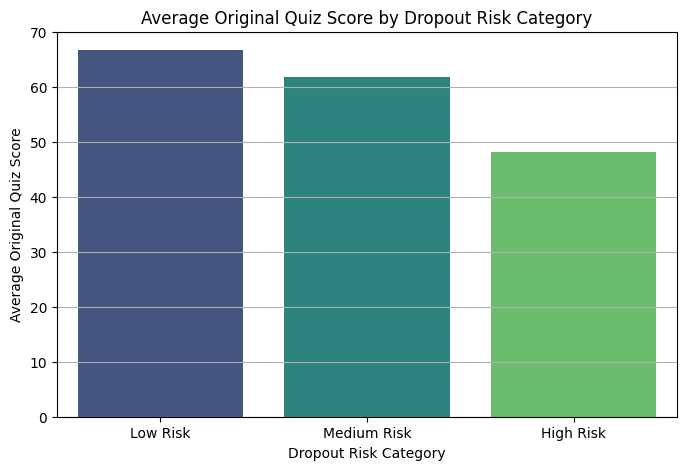

In [18]:
print("\nComparing quiz scores across risk categories:")

# We need the original quiz scores for this comparison.
# Since df['quiz_avg_score'] was modified (standardized) for risk score calculation,
# we will create a temporary DataFrame to get the original quiz scores.

# Re-read the dataset to get original 'quiz_avg_score' values
df_original = pd.read_csv('/content/student_dropout_risk_dataset.csv')

# Create a temporary DataFrame combining risk classification with original quiz scores
temp_quiz_df = pd.DataFrame({
    'dropout_risk_classification': df['dropout_risk_classification'],
    'original_quiz_avg_score': df_original['quiz_avg_score']
})

# Group by dropout_risk_classification and calculate the mean original quiz_avg_score
quiz_score_by_risk = temp_quiz_df.groupby('dropout_risk_classification')['original_quiz_avg_score'].mean().sort_values(ascending=False)

print("Average original quiz score by risk category:")
display(quiz_score_by_risk)

# Visualize the comparison using a bar plot
plt.figure(figsize=(8, 5))
sns.barplot(x=quiz_score_by_risk.index, y=quiz_score_by_risk.values, palette='viridis', hue=quiz_score_by_risk.index, legend=False)
plt.title('Average Original Quiz Score by Dropout Risk Category')
plt.xlabel('Dropout Risk Category')
plt.ylabel('Average Original Quiz Score')
plt.grid(axis='y')
plt.show()


Identifying countries with the highest number of high-risk students:
Top countries with the highest number of high-risk students:


,country,number_of_high_risk_students
0,UK,27
1,UAE,26
2,USA,24
3,Australia,23
4,Canada,17


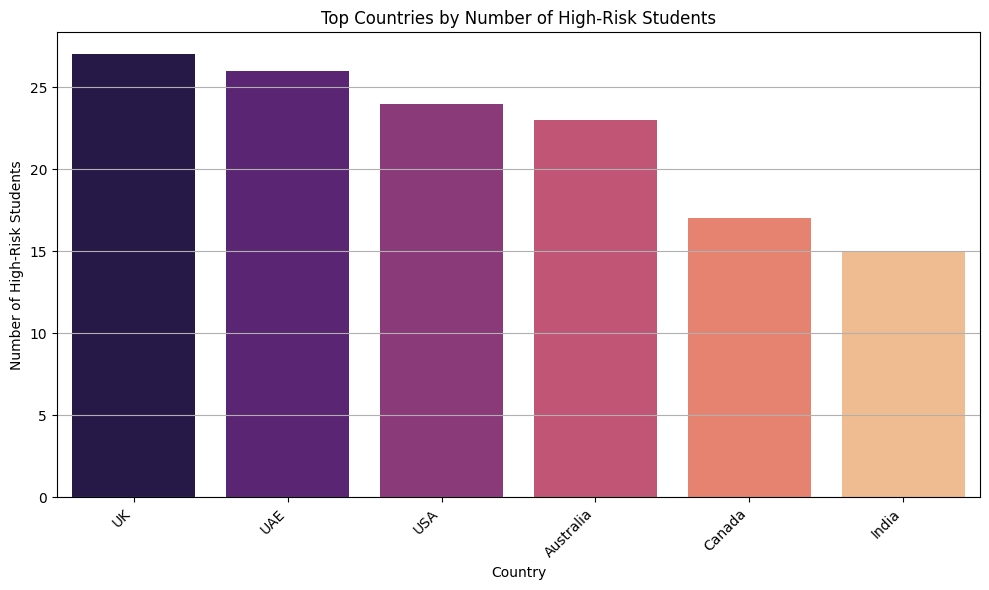

In [15]:
print("\nIdentifying countries with the highest number of high-risk students:")

# Filter for high-risk students
high_risk_students = df[df['dropout_risk_classification'] == 'High Risk']

# Count high-risk students by country
high_risk_by_country = high_risk_students['country'].value_counts().reset_index()
high_risk_by_country.columns = ['country', 'number_of_high_risk_students']

# Sort by number of high-risk students in descending order
high_risk_by_country_sorted = high_risk_by_country.sort_values(by='number_of_high_risk_students', ascending=False)

print("Top countries with the highest number of high-risk students:")
display(high_risk_by_country_sorted.head())

# Visualize the top countries
plt.figure(figsize=(10, 6))
sns.barplot(x='country', y='number_of_high_risk_students', data=high_risk_by_country_sorted.head(10), palette='magma', hue='country', legend=False)
plt.title('Top Countries by Number of High-Risk Students')
plt.xlabel('Country')
plt.ylabel('Number of High-Risk Students')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y')
plt.tight_layout()
plt.show()